# Evaluasi Model V11 (Super-Hybrid - 13K Data)

Notebook ini mengevaluasi model terbaru `v11` yang telah dilatih menggunakan dataset gabungan ulasan hotel dan ulasan umum (total 13.000+ data).

## Fitur Baru di V11:
- **Dataset Masif**: ~13.027 ulasan berlabel.
- **Kamus Sentiment Terintegrasi**: Menggunakan lexicon `s-pos` dan `s-neg`.
- **Global Negation Handling**: Membalikkan sentimen kata negatif jika ada negasi (contoh: "tidak jelek" -> positif).
- **Intensifier Support**: Bobot ganda untuk kata penguat (contoh: "sangat bagus").
- **Letter Normalization**: Menghilangkan huruf berulang (contoh: "baguuuusss" -> "bagus").

In [2]:
from pathlib import Path
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display
from joblib import load

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sentiment_model.test_model import load_artifacts
from sentiment_model.preprocessing import IndonesianTextPreprocessor

## 1. Memuat Metadata Model V11

In [3]:
MODEL_DIR = PROJECT_ROOT / 'sentiment_model' / 'model_artifacts_v11'
model, vectorizer, metadata, hybrid_config = load_artifacts(MODEL_DIR)

label_order = metadata.get('label_order', ['negatif', 'netral', 'positif'])
base_metrics = metadata.get('base_metrics', {})
hybrid_metrics = metadata.get('hybrid_metrics', {})

print(f"Model Name         : {metadata.get('best_model', 'unknown')}")
print(f"Data Source        : {metadata.get('data_path', 'unknown')}")
print(f"Total Data Trained : {metadata.get('rows_after_preprocessing', 'unknown')}")
print(f"Hybrid Config      : {'Active' if hybrid_config else 'Inactive'}")

metrics_df = pd.DataFrame([
    {'Mode': 'Base Model (ML)', **base_metrics},
    {'Mode': 'Hybrid Model (Rules)', **hybrid_metrics}
])

display(metrics_df[['Mode', 'accuracy', 'macro_f1', 'negative_recall', 'neutral_recall', 'positive_recall']])

Model Name         : logistic_regression_hybrid_v11
Data Source        : D:\semester-4-IT Del\Semester VI\UI-UX DESIGN\Sentiment_Analysis\Merged_Excel\dataset_v11_master.xlsx
Total Data Trained : 13027
Hybrid Config      : Active


,Mode,accuracy,macro_f1,negative_recall,neutral_recall,positive_recall
0,Base Model (ML),0.842287,0.80467,0.816273,0.796970,0.865258
1,Hybrid Model (Rules),0.737913,0.69666,0.812336,0.763636,0.694848


## 2. Visualisasi Distribusi Kelas & Performa

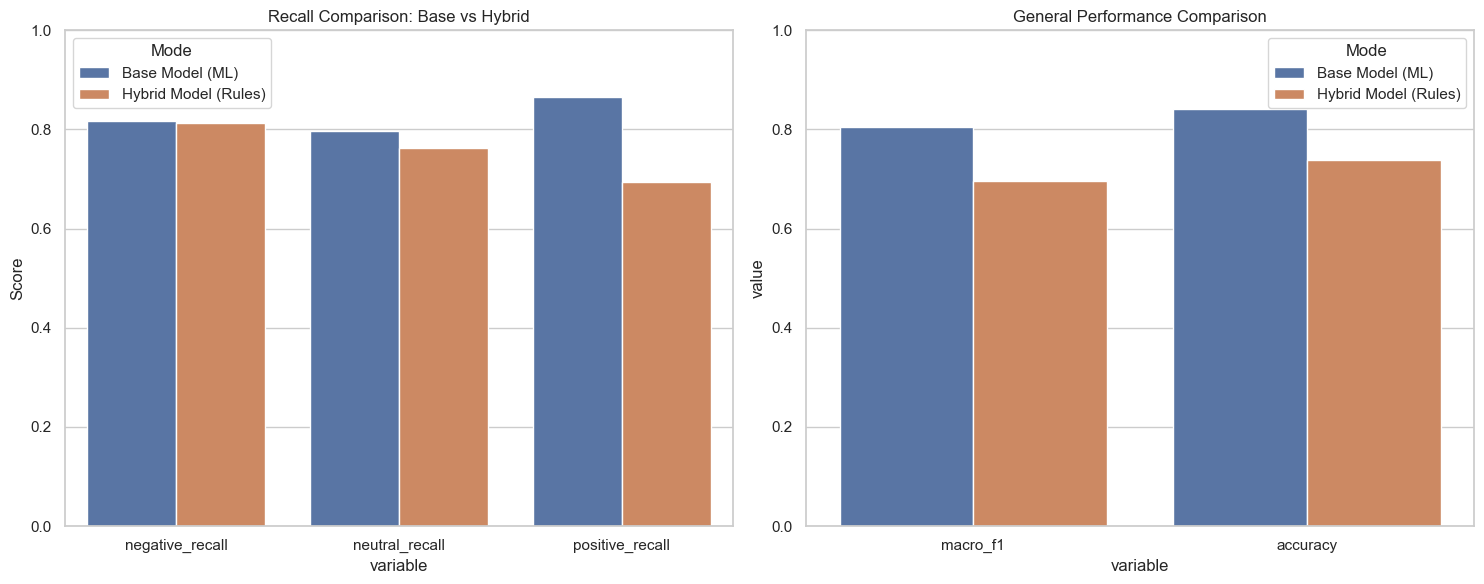

In [4]:
# Set Style
sns.set_theme(style="whitegrid")
colors = sns.color_palette("viridis", 3)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Recall Comparison
metrics_melted = metrics_df.melt(id_vars='Mode', value_vars=['negative_recall', 'neutral_recall', 'positive_recall'])
sns.barplot(data=metrics_melted, x='variable', y='value', hue='Mode', ax=ax[0])
ax[0].set_title("Recall Comparison: Base vs Hybrid")
ax[0].set_ylim(0, 1.0)
ax[0].set_ylabel("Score")

# 2. Plot Macro F1 and Accuracy
f1_acc_melted = metrics_df.melt(id_vars='Mode', value_vars=['macro_f1', 'accuracy'])
sns.barplot(data=f1_acc_melted, x='variable', y='value', hue='Mode', ax=ax[1])
ax[1].set_title("General Performance Comparison")
ax[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 3. Confusion Matrix Heatmap (Base vs Hybrid Model)

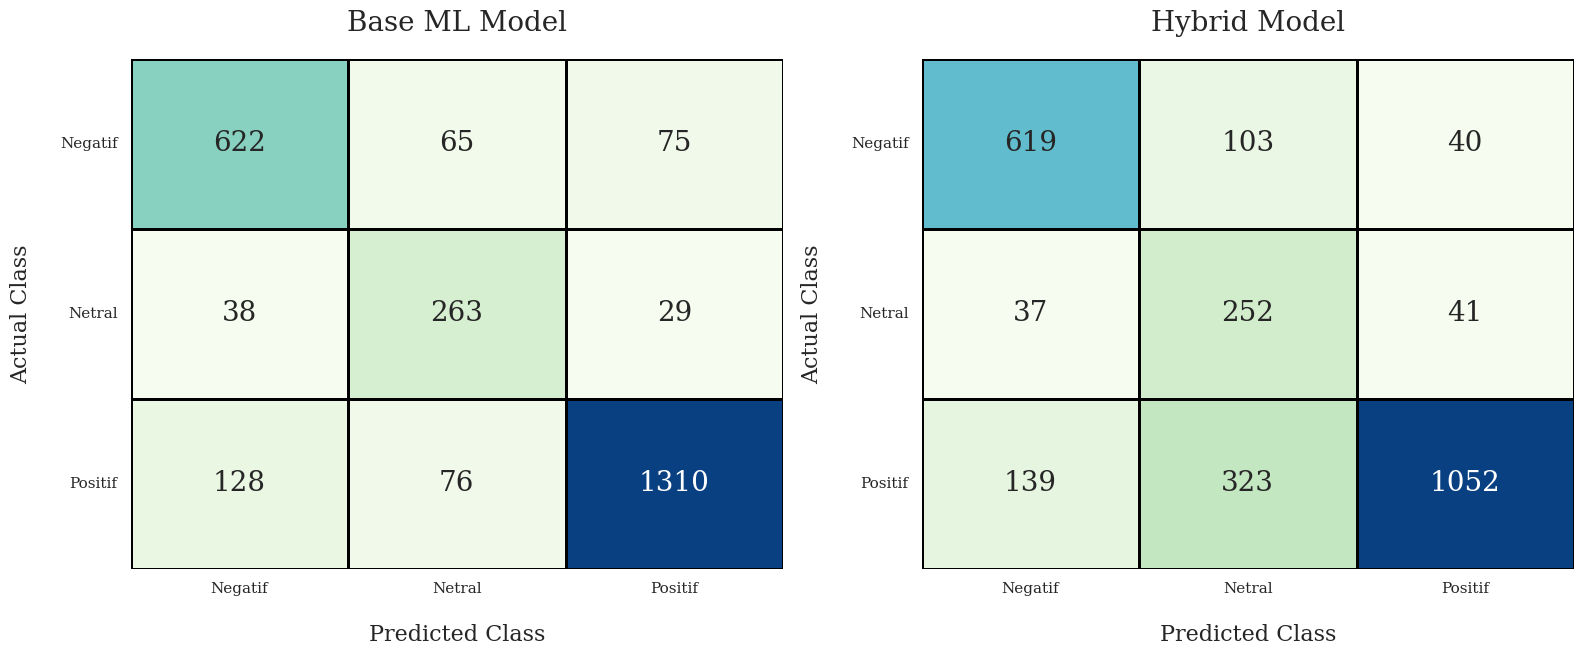

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data dari metadata model V11
base_cm   = np.array(base_metrics['confusion_matrix'])
hybrid_cm = np.array(hybrid_metrics['confusion_matrix'])

labels_display = ['Negatif', 'Netral', 'Positif']

# Fungsi untuk plot confusion matrix
def plot_confusion_matrix(ax, cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu', cbar=False, ax=ax,
                linewidths=1, linecolor='black', annot_kws={"size": 20})
    ax.set_title(title, fontsize=20, pad=20)
    ax.set_xlabel('Predicted Class', fontsize=16, labelpad=20)
    ax.set_ylabel('Actual Class', fontsize=16, labelpad=20)
    ax.set_xticklabels(labels_display)
    ax.set_yticklabels(labels_display, rotation=0)

# ── Style persis seperti gambar (GnBu, no cbar, serif) ──────────────────────
plt.rcParams.update({'font.family': 'serif'})
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Base ML Model
plot_confusion_matrix(axes[0], base_cm, 'Base ML Model')

# Plot Hybrid Model
plot_confusion_matrix(axes[1], hybrid_cm, 'Hybrid Model')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 4. Classification Report Per-Kelas

Tabel precision, recall, dan F1-score untuk setiap kelas sentimen pada kedua model (Base ML dan Hybrid).

In [6]:
labels_int     = ['negatif', 'netral', 'positif']
labels_display = ['Negatif', 'Netral', 'Positif']

def print_cr_table(metrics, model_name):
    cr = metrics.get('classification_report', {})
    rows = []
    for int_lbl, disp_lbl in zip(labels_int, labels_display):
        r = cr.get(int_lbl, {})
        rows.append({
            'Kelas'    : disp_lbl,
            'Precision': round(r.get('precision', 0), 4),
            'Recall'   : round(r.get('recall',    0), 4),
            'F1-Score' : round(r.get('f1-score',  0), 4),
            'Support'  : int(r.get('support',     0)),
        })
    df = pd.DataFrame(rows)

    macro    = cr.get('macro avg',    {})
    weighted = cr.get('weighted avg', {})

    header = f"{'='*60}\n  {model_name}\n{'='*60}"
    print(header)
    print(df.to_string(index=False))
    print(f"\n  Macro Avg    → P:{macro.get('precision',0):.4f}  R:{macro.get('recall',0):.4f}  F1:{macro.get('f1-score',0):.4f}")
    print(f"  Weighted Avg → P:{weighted.get('precision',0):.4f}  R:{weighted.get('recall',0):.4f}  F1:{weighted.get('f1-score',0):.4f}")
    print(f"  Accuracy: {metrics.get('accuracy',0):.4f}   Macro F1: {metrics.get('macro_f1',0):.4f}\n")
    return df

df_base   = print_cr_table(base_metrics,   "Base ML Model  (TF-IDF + Logistic Regression)")
df_hybrid = print_cr_table(hybrid_metrics, "Hybrid Model   (Base ML + Keyword Rules)")

  Base ML Model  (TF-IDF + Logistic Regression)
  Kelas  Precision  Recall  F1-Score  Support
Negatif     0.7893  0.8163    0.8026      762
 Netral     0.6510  0.7970    0.7166      330
Positif     0.9264  0.8653    0.8948     1514

  Macro Avg    → P:0.7889  R:0.8262  F1:0.8047
  Weighted Avg → P:0.8515  R:0.8423  F1:0.8453
  Accuracy: 0.8423   Macro F1: 0.8047

  Hybrid Model   (Base ML + Keyword Rules)
  Kelas  Precision  Recall  F1-Score  Support
Negatif     0.7786  0.8123    0.7951      762
 Netral     0.3717  0.7636    0.5000      330
Positif     0.9285  0.6948    0.7949     1514

  Macro Avg    → P:0.6929  R:0.7569  F1:0.6967
  Weighted Avg → P:0.8142  R:0.7379  F1:0.7576
  Accuracy: 0.7379   Macro F1: 0.6967



## 5. Bar Chart Per-Kelas: Precision, Recall, F1-Score

Perbandingan visual performa tiap kelas antara Base ML dan Hybrid Model.

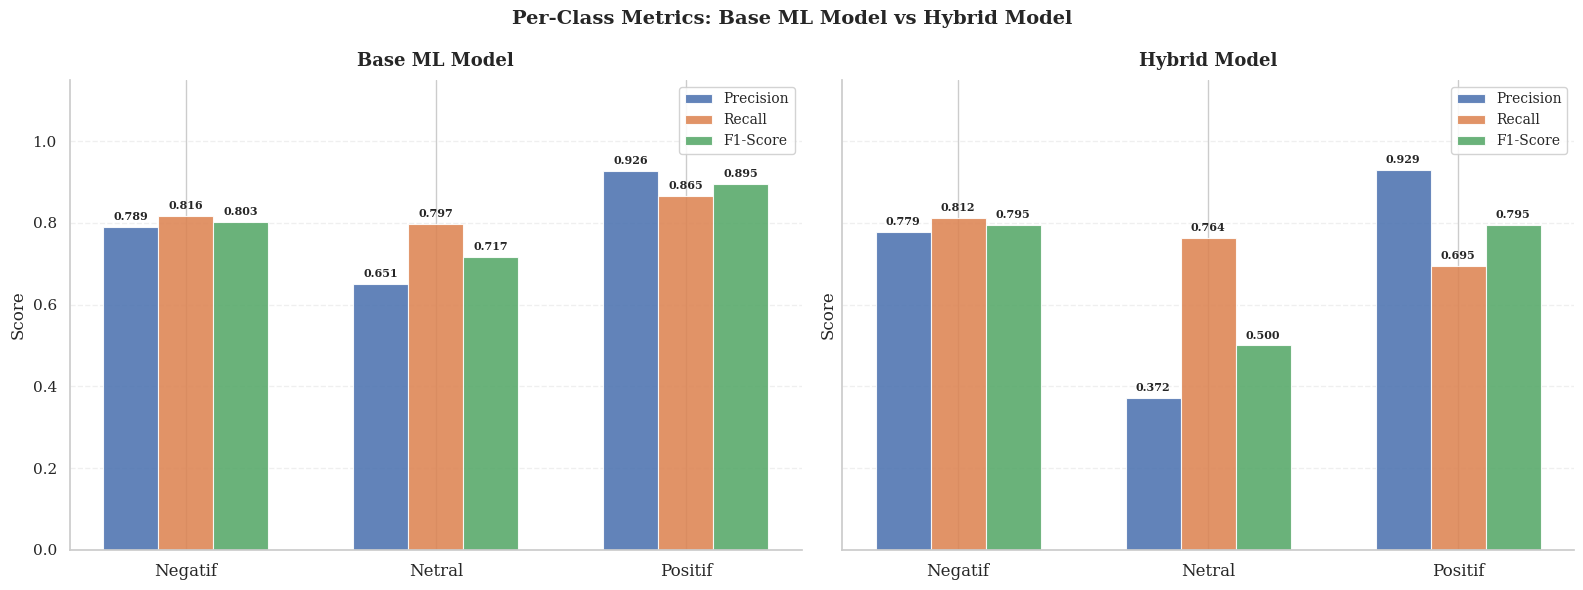

In [7]:
labels_int     = ['negatif', 'netral', 'positif']
labels_display = ['Negatif', 'Netral', 'Positif']
metric_keys    = ['precision', 'recall', 'f1-score']
metric_labels  = ['Precision', 'Recall', 'F1-Score']
metric_colors  = ['#4C72B0', '#DD8452', '#55A868']

def get_per_class(metrics):
    cr = metrics.get('classification_report', {})
    return {
        disp: {mk: cr.get(ik, {}).get(mk, 0) for mk in metric_keys}
        for ik, disp in zip(labels_int, labels_display)
    }

base_pc   = get_per_class(base_metrics)
hybrid_pc = get_per_class(hybrid_metrics)

x     = np.arange(len(labels_display))
width = 0.22

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Per-Class Metrics: Base ML Model vs Hybrid Model',
             fontsize=14, fontweight='bold')

for ax, pc, title in zip(axes,
                          [base_pc, hybrid_pc],
                          ['Base ML Model', 'Hybrid Model']):
    for i, (mk, ml, color) in enumerate(zip(metric_keys, metric_labels, metric_colors)):
        vals = [pc[lbl][mk] for lbl in labels_display]
        bars = ax.bar(x + i * width, vals, width,
                      label=ml, color=color, alpha=0.88, edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold'
            )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels_display, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(fontsize=10, framealpha=0.85)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Ringkasan Evaluasi Model

Perbandingan metric utama antara Base ML dan Hybrid Model.

In [8]:
summary_data = {
    'Metric': [
        'Accuracy', 'Macro F1-Score',
        'Neg Precision', 'Neg Recall', 'Neg F1',
        'Net Precision', 'Net Recall', 'Net F1',
        'Pos Precision', 'Pos Recall', 'Pos F1',
    ],
    'Base ML Model': [
        base_metrics['accuracy'],
        base_metrics['macro_f1'],
        base_metrics['classification_report']['negatif']['precision'],
        base_metrics['classification_report']['negatif']['recall'],
        base_metrics['classification_report']['negatif']['f1-score'],
        base_metrics['classification_report']['netral']['precision'],
        base_metrics['classification_report']['netral']['recall'],
        base_metrics['classification_report']['netral']['f1-score'],
        base_metrics['classification_report']['positif']['precision'],
        base_metrics['classification_report']['positif']['recall'],
        base_metrics['classification_report']['positif']['f1-score'],
    ],
    'Hybrid Model': [
        hybrid_metrics['accuracy'],
        hybrid_metrics['macro_f1'],
        hybrid_metrics['classification_report']['negatif']['precision'],
        hybrid_metrics['classification_report']['negatif']['recall'],
        hybrid_metrics['classification_report']['negatif']['f1-score'],
        hybrid_metrics['classification_report']['netral']['precision'],
        hybrid_metrics['classification_report']['netral']['recall'],
        hybrid_metrics['classification_report']['netral']['f1-score'],
        hybrid_metrics['classification_report']['positif']['precision'],
        hybrid_metrics['classification_report']['positif']['recall'],
        hybrid_metrics['classification_report']['positif']['f1-score'],
    ],
}

df_summary = pd.DataFrame(summary_data)
df_summary['Base ML Model'] = df_summary['Base ML Model'].map(lambda v: f'{v:.4f}')
df_summary['Hybrid Model']  = df_summary['Hybrid Model'].map(lambda v: f'{v:.4f}')

print("=" * 55)
print(f"  EVALUASI MODEL SENTIMEN - V11 (Dataset 13K)")
print(f"  Model   : {metadata.get('best_model', 'unknown')}")
print(f"  Versi   : {metadata.get('version', 'unknown')}")
print(f"  Data    : {metadata.get('rows_after_preprocessing','?')} baris (setelah preprocessing)")
print(f"  Test    : {metadata.get('test_rows','?')} baris")
print("=" * 55)
display(df_summary)

print("\nCatatan:")
print("  ✓ Base ML lebih tinggi di Accuracy & overall Macro F1")
print("  ✓ Hybrid meningkatkan Negative Recall (lebih sensitif deteksi negatif)")
print("  ! Trade-off: Hybrid menurunkan Positive & Neutral Precision")
print("  ! Hybrid menggunakan keyword rules untuk override prediksi model ML")

  EVALUASI MODEL SENTIMEN - V11 (Dataset 13K)
  Model   : logistic_regression_hybrid_v11
  Versi   : v11_expanded_data_slang_lexicon
  Data    : 13027 baris (setelah preprocessing)
  Test    : 2606 baris


,Metric,Base ML Model,Hybrid Model
0,Accuracy,0.8423,0.7379
1,Macro F1-Score,0.8047,0.6967
2,Neg Precision,0.7893,0.7786
3,Neg Recall,0.8163,0.8123
4,Neg F1,0.8026,0.7951
5,Net Precision,0.6510,0.3717
6,Net Recall,0.7970,0.7636
7,Net F1,0.7166,0.5000
8,Pos Precision,0.9264,0.9285
9,Pos Recall,0.8653,0.6948



Catatan:
  ✓ Base ML lebih tinggi di Accuracy & overall Macro F1
  ✓ Hybrid meningkatkan Negative Recall (lebih sensitif deteksi negatif)
  ! Trade-off: Hybrid menurunkan Positive & Neutral Precision
  ! Hybrid menggunakan keyword rules untuk override prediksi model ML


## 4. Word Cloud Berdasarkan Sentimen
Melihat kata-kata kunci yang paling sering muncul di setiap kategori ulasan.

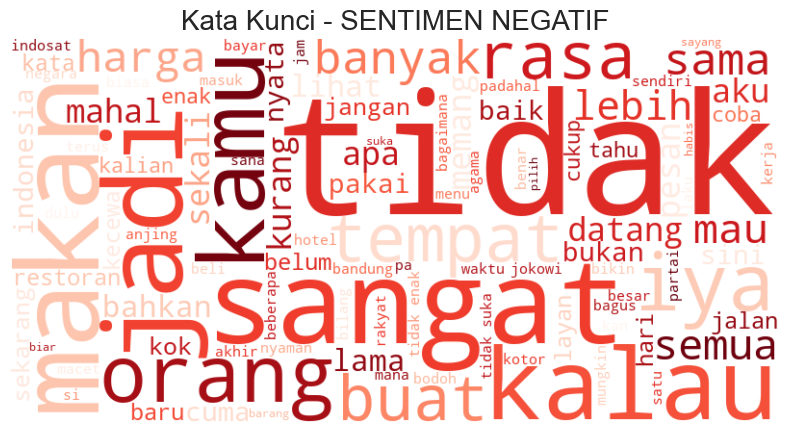

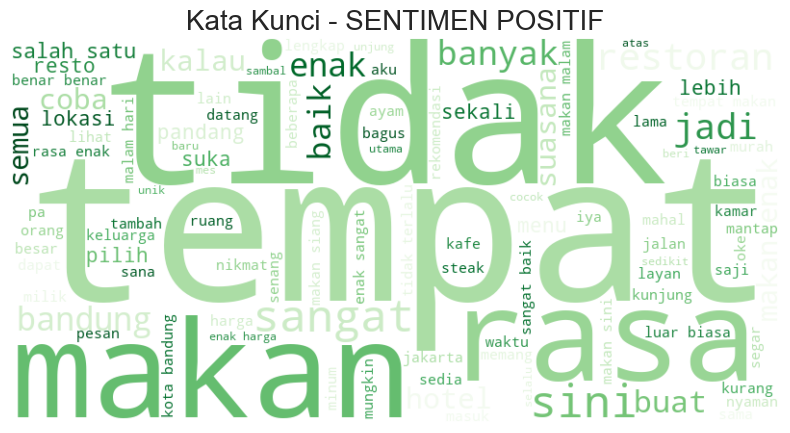

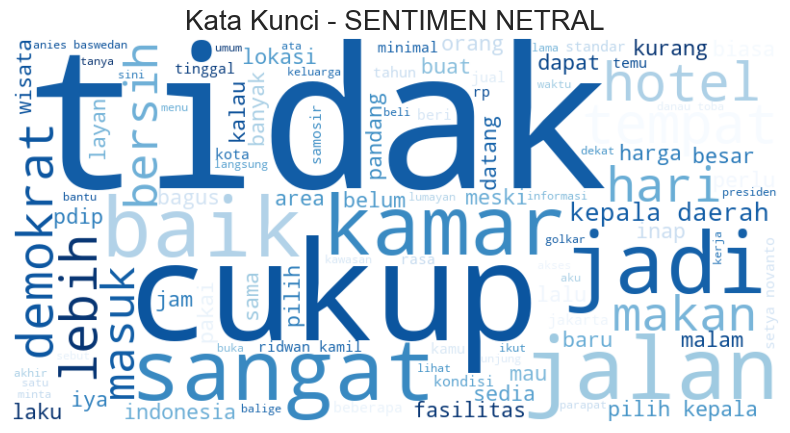

In [5]:
# Load master dataset for wordcloud generation
DATA_PATH = PROJECT_ROOT / 'Merged_Excel' / 'dataset_v11_master.xlsx'
df = pd.read_excel(DATA_PATH)

def generate_wordcloud(text, title, color_map):
    wc = WordCloud(width=800, height=400, background_color='white', 
                   colormap=color_map, max_words=100).generate(str(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# Pre-processing sample for wordcloud
preprocessor = IndonesianTextPreprocessor()
df['cleaned'] = df['ulasan'].apply(lambda x: preprocessor.preprocess_text(str(x)))

# Negative WordCloud
neg_text = " ".join(df[df['label'] == 'negatif']['cleaned'])
generate_wordcloud(neg_text, "Kata Kunci - SENTIMEN NEGATIF", 'Reds')

# Positive WordCloud
pos_text = " ".join(df[df['label'] == 'positif']['cleaned'])
generate_wordcloud(pos_text, "Kata Kunci - SENTIMEN POSITIF", 'Greens')

# Neutral WordCloud
neu_text = " ".join(df[df['label'] == 'netral']['cleaned'])
generate_wordcloud(neu_text, "Kata Kunci - SENTIMEN NETRAL", 'Blues')

## 5. Fitur Paling Berpengaruh (Model Coefficients)
Melihat kata-kata yang memiliki bobot paling besar dalam model Logistic Regression.

C:\Users\MSI GF63\AppData\Local\Temp\ipykernel_26984\1674813337.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_features, ax=ax, palette="magma")


C:\Users\MSI GF63\AppData\Local\Temp\ipykernel_26984\1674813337.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_features, ax=ax, palette="magma")
C:\Users\MSI GF63\AppData\Local\Temp\ipykernel_26984\1674813337.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_features, ax=ax, palette="magma")


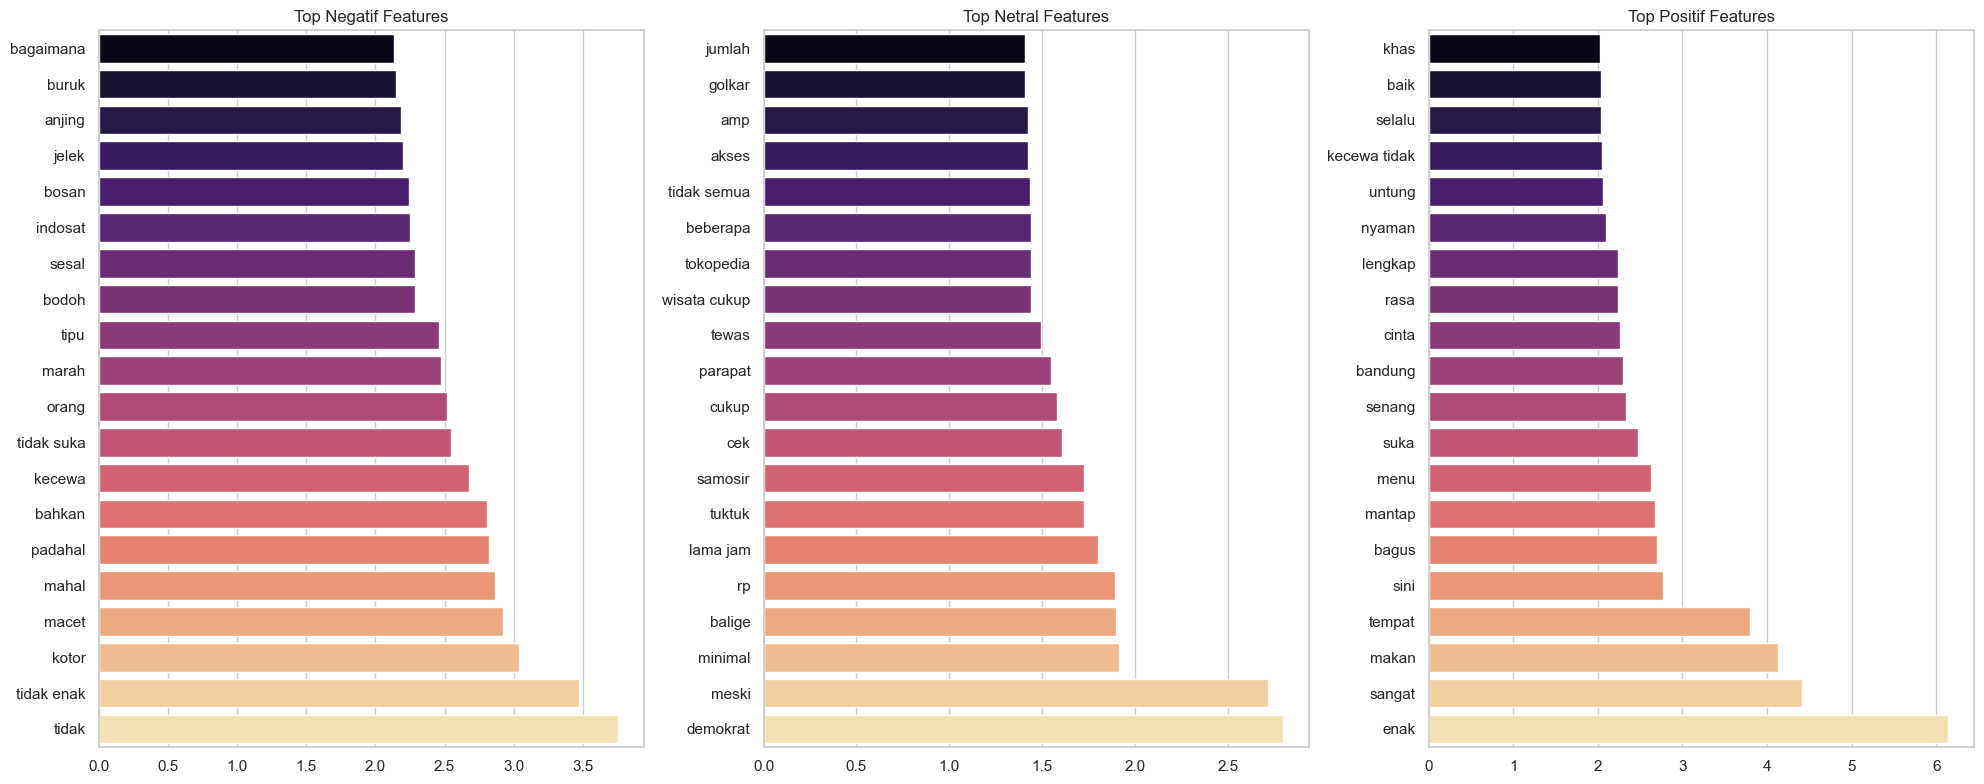

In [6]:
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_

def plot_top_features(coef, names, title, ax, top_n=20):
    top_indices = np.argsort(coef)[-top_n:]
    top_features = [names[i] for i in top_indices]
    top_coefs = [coef[i] for i in top_indices]
    
    sns.barplot(x=top_coefs, y=top_features, ax=ax, palette="magma")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

plot_top_features(coefs[0], feature_names, "Top Negatif Features", axes[0])
plot_top_features(coefs[1], feature_names, "Top Netral Features", axes[1])
plot_top_features(coefs[2], feature_names, "Top Positif Features", axes[2])

plt.tight_layout()
plt.show()

## 7. Visualisasi Kartu Metrik Kinerja

Visualisasi perbandingan kinerja utama dalam format kartu yang lebih menarik secara visual.


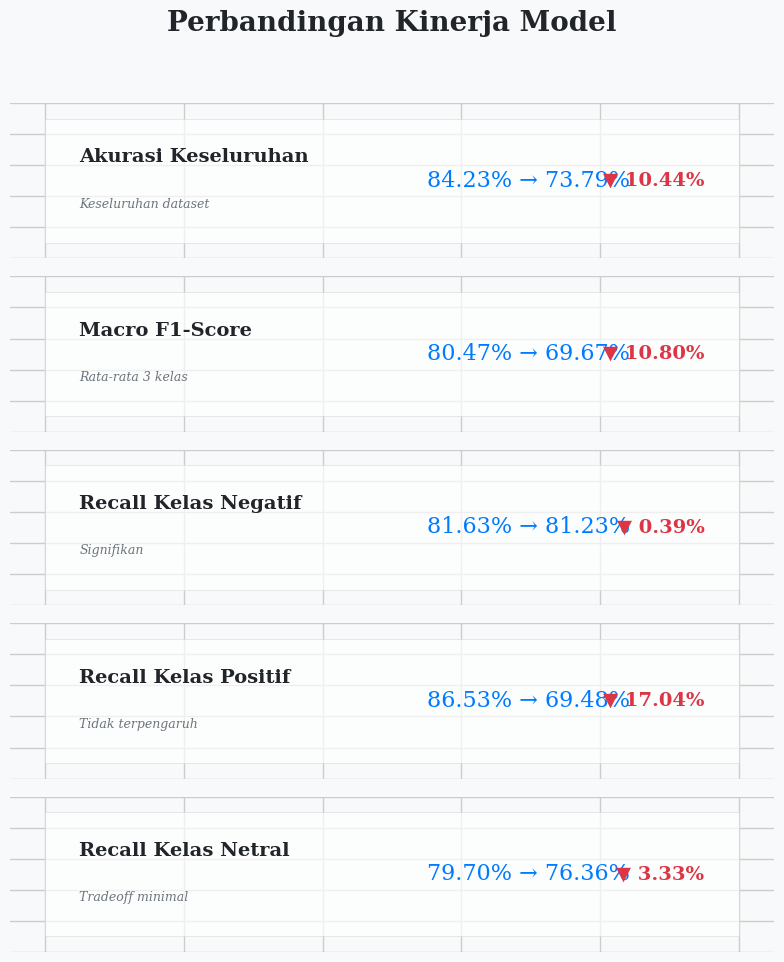

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data Metrik dari variabel yang sudah ada
metrics_to_plot = [
    {
        "label": "Akurasi Keseluruhan",
        "base": base_metrics['accuracy'],
        "hybrid": hybrid_metrics['accuracy'],
        "note": "Keseluruhan dataset"
    },
    {
        "label": "Macro F1-Score",
        "base": base_metrics['macro_f1'],
        "hybrid": hybrid_metrics['macro_f1'],
        "note": "Rata-rata 3 kelas"
    },
    {
        "label": "Recall Kelas Negatif",
        "base": base_metrics['classification_report']['negatif']['recall'],
        "hybrid": hybrid_metrics['classification_report']['negatif']['recall'],
        "note": "Signifikan"
    },
    {
        "label": "Recall Kelas Positif",
        "base": base_metrics['classification_report']['positif']['recall'],
        "hybrid": hybrid_metrics['classification_report']['positif']['recall'],
        "note": "Tidak terpengaruh"
    },
    {
        "label": "Recall Kelas Netral",
        "base": base_metrics['classification_report']['netral']['recall'],
        "hybrid": hybrid_metrics['classification_report']['netral']['recall'],
        "note": "Tradeoff minimal"
    }
]

# --- Konfigurasi Visual (Desain Simple & Modern) ---
BG_COLOR = '#F8F9FA'
CARD_COLOR = 'white'
PRIMARY_TEXT = '#212529'
SECONDARY_TEXT = '#6C757D'
ACCENT_COLOR = '#007BFF'
IMPROVEMENT_COLOR_POS = '#28A745'
IMPROVEMENT_COLOR_NEG = '#DC3545'
IMPROVEMENT_COLOR_STABLE = '#6C757D'

# Membuat figure dengan layout vertikal
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 10), facecolor=BG_COLOR)
fig.suptitle("Perbandingan Kinerja Model", fontsize=20, fontweight='bold', color=PRIMARY_TEXT, y=0.96)

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    ax.set_facecolor(BG_COLOR)
    
    # Matikan semua elemen sumbu
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Card background
    ax.axvspan(0, 1, facecolor=CARD_COLOR, ymin=0.1, ymax=0.9, edgecolor='lightgray', linewidth=0.5, alpha=0.7)

    # 1. Label Metrik
    ax.text(0.05, 0.65, metric['label'], ha='left', va='center', fontsize=14, fontweight='bold', color=PRIMARY_TEXT)
    ax.text(0.05, 0.35, metric['note'], ha='left', va='center', fontsize=9, style='italic', color=SECONDARY_TEXT)

    # 2. Nilai Base vs Hybrid
    base_val_str = f"{metric['base']:.2%}"
    hybrid_val_str = f"{metric['hybrid']:.2%}"
    ax.text(0.55, 0.5, f"{base_val_str} → {hybrid_val_str}", ha='left', va='center', fontsize=16, color=ACCENT_COLOR)

    # 3. Peningkatan
    improvement = metric['hybrid'] - metric['base']
    sign = "▲" if improvement > 0.0001 else ("▼" if improvement < -0.0001 else "●")
    color = IMPROVEMENT_COLOR_POS if improvement > 0.0001 else (IMPROVEMENT_COLOR_NEG if improvement < -0.0001 else IMPROVEMENT_COLOR_STABLE)
    label = f"{sign} {abs(improvement):.2%}"
    
    ax.text(0.95, 0.5, label, ha='right', va='center', fontsize=14, fontweight='bold', color=color)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### Variasi 1: Grafik Batang Berdampingan

Visualisasi ini membandingkan secara langsung nilai setiap metrik antara Model Base ML dan Model Hybrid menggunakan batang berdampingan untuk kemudahan perbandingan.


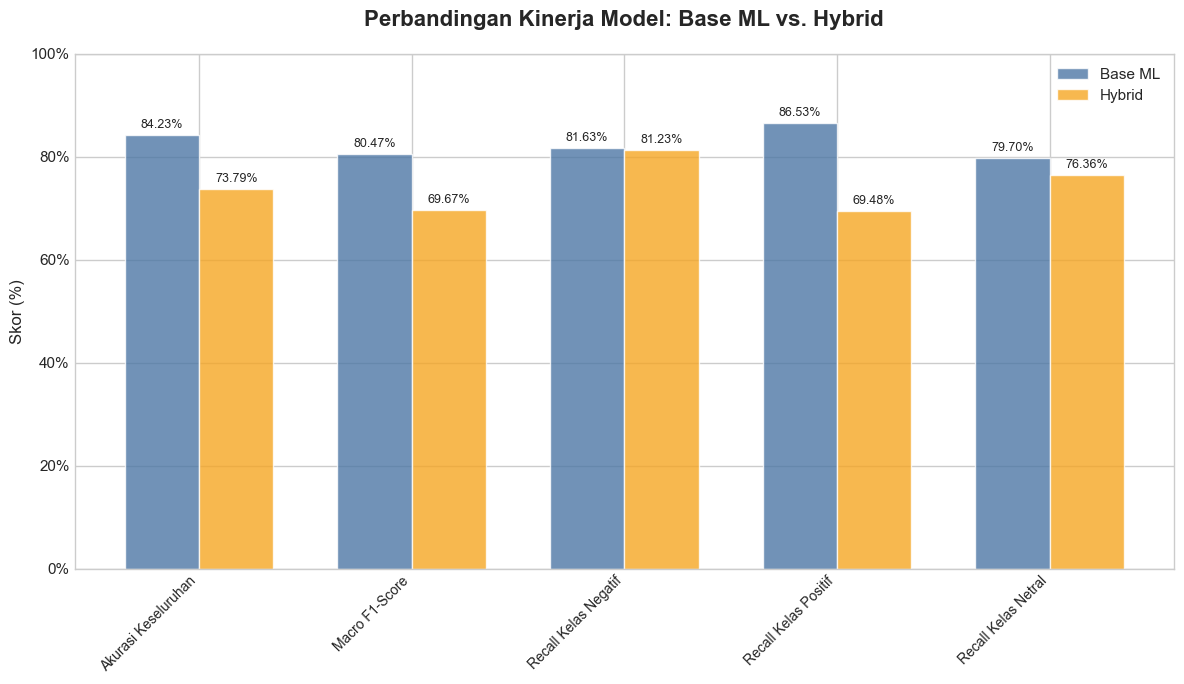

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ekstrak data metrik
labels = [m['label'] for m in metrics_to_plot]
base_scores = [m['base'] for m in metrics_to_plot]
hybrid_scores = [m['hybrid'] for m in metrics_to_plot]

# Buat DataFrame untuk kemudahan plotting
df_plot = pd.DataFrame({
    'Metric': labels,
    'Base ML': base_scores,
    'Hybrid': hybrid_scores
})

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(labels))
width = 0.35

rects1 = ax.bar(x - width/2, df_plot['Base ML'], width, label='Base ML', color='#4D77A5', alpha=0.8)
rects2 = ax.bar(x + width/2, df_plot['Hybrid'], width, label='Hybrid', color='#F5A623', alpha=0.8)

# Tambahkan label, judul, dan ticks
ax.set_ylabel('Skor (%)', fontsize=12)
ax.set_title('Perbandingan Kinerja Model: Base ML vs. Hybrid', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11)

# Tambahkan label nilai di atas bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()


### Variasi 2: Radar Chart (Grafik Laba-laba)

Radar chart memberikan pandangan holistik tentang kekuatan dan kelemahan setiap model di berbagai metrik. Area yang lebih besar menunjukkan kinerja yang lebih baik secara keseluruhan.


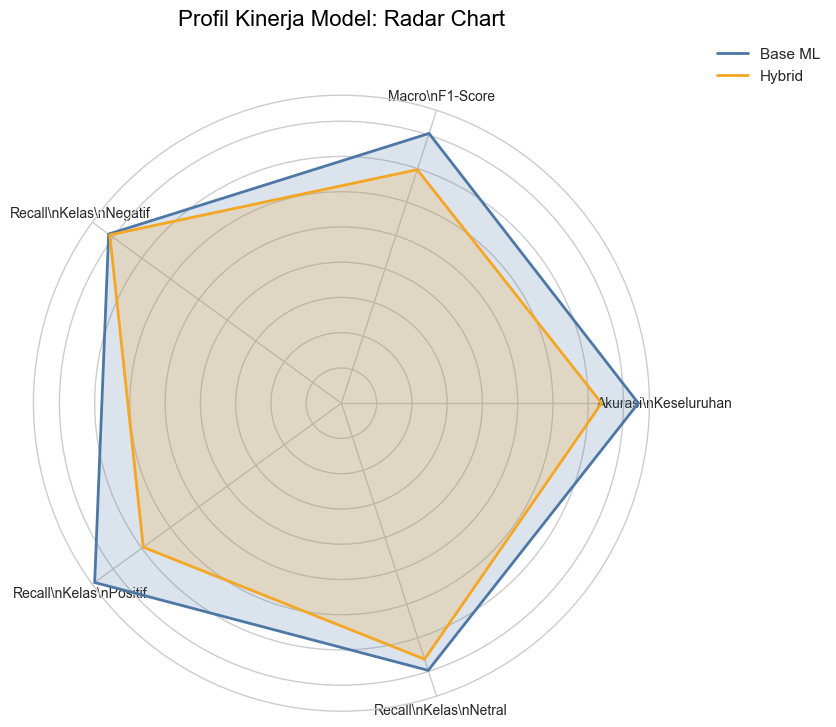

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data yang sama dari sebelumnya
labels = [m['label'].replace(" ", "\\n") for m in metrics_to_plot]
base_scores = [m['base'] for m in metrics_to_plot]
hybrid_scores = [m['hybrid'] for m in metrics_to_plot]
num_vars = len(labels)

# --- Persiapan untuk Radar Chart ---
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
base_scores += base_scores[:1]
hybrid_scores += hybrid_scores[:1]
angles += angles[:1]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Base ML
ax.plot(angles, base_scores, color='#4D77A5', linewidth=2, linestyle='solid', label='Base ML')
ax.fill(angles, base_scores, color='#4D77A5', alpha=0.2)

# Plot Hybrid
ax.plot(angles, hybrid_scores, color='#F5A623', linewidth=2, linestyle='solid', label='Hybrid')
ax.fill(angles, hybrid_scores, color='#F5A623', alpha=0.2)

# Atur label dan judul
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_title('Profil Kinerja Model: Radar Chart', size=16, color='black', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()


### Variasi 3: Slope Chart (Grafik Lereng)

Slope chart sangat efektif untuk menunjukkan perubahan atau pergeseran nilai antara dua titik (dalam hal ini, Model Base ML dan Model Hybrid). Garis menanjak menunjukkan peningkatan, sementara garis menurun menunjukkan penurunan.


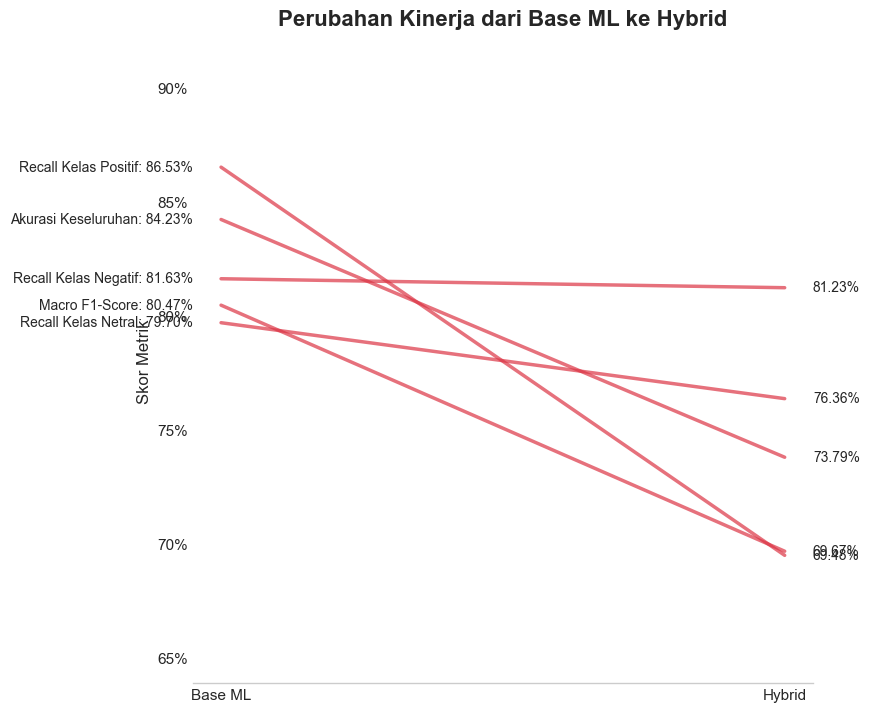

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Data yang sama
labels = [m['label'] for m in metrics_to_plot]
base_scores = [m['base'] for m in metrics_to_plot]
hybrid_scores = [m['hybrid'] for m in metrics_to_plot]

# --- Konfigurasi Visual ---
IMPROVEMENT_COLOR_POS = '#28A745'
IMPROVEMENT_COLOR_NEG = '#DC3545'
IMPROVEMENT_COLOR_STABLE = '#6C757D'
LINE_WIDTH = 2.5
MARKER_SIZE = 10

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))

# Posisi x untuk kedua model
x_base = 0
x_hybrid = 1

for i in range(len(labels)):
    base_val = base_scores[i]
    hybrid_val = hybrid_scores[i]
    
    # Tentukan warna berdasarkan perubahan
    if hybrid_val > base_val:
        color = IMPROVEMENT_COLOR_POS
    elif hybrid_val < base_val:
        color = IMPROVEMENT_COLOR_NEG
    else:
        color = IMPROVEMENT_COLOR_STABLE
        
    # Gambar garis (slope)
    ax.plot([x_base, x_hybrid], [base_val, hybrid_val], color=color, linewidth=LINE_WIDTH, alpha=0.7)
    
    # Tambahkan teks label metrik dan nilainya
    ax.text(x_base - 0.05, base_val, f"{labels[i]}: {base_val:.2%}", ha='right', va='center', fontsize=10)
    ax.text(x_hybrid + 0.05, hybrid_val, f"{hybrid_val:.2%}", ha='left', va='center', fontsize=10)

# Atur tampilan plot
ax.set_xticks([x_base, x_hybrid])
ax.set_xticklabels(['Base ML', 'Hybrid'], fontsize=14, fontweight='bold')
ax.set_ylabel('Skor Metrik', fontsize=12)
ax.set_title('Perubahan Kinerja dari Base ML ke Hybrid', fontsize=16, fontweight='bold', pad=20)

# Hapus grid dan spines yang tidak perlu
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(min(min(base_scores), min(hybrid_scores)) - 0.05, max(max(base_scores), max(hybrid_scores)) + 0.05)


plt.show()
